In [29]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

import warnings
warnings.filterwarnings("ignore")

In [30]:
fraud_test = pd.read_csv("/content/fraudTest.csv")


fraud_test.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,...,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,...,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0
2,2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,...,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0
3,3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,...,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0
4,4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,...,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0


In [31]:
fraud_train = pd.read_csv("/content/fraudTrain.csv")


In [32]:
fraud_train.shape

(1296675, 23)

In [33]:
fraud_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long              

In [34]:
fraud_train.columns

Index(['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category',
       'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud'],
      dtype='object')

In [35]:
fraud_train.isnull().sum()

,0
Unnamed: 0,0
trans_date_trans_time,0
cc_num,0
merchant,0
category,0
amt,0
first,0
last,0
gender,0
street,0


In [36]:
fraud_test.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,...,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,...,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0
2,2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,...,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0
3,3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,...,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0
4,4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,...,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0


In [37]:
fraud_test.shape

(555719, 23)

In [38]:
fraud_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 555719 entries, 0 to 555718
Data columns (total 23 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Unnamed: 0             555719 non-null  int64  
 1   trans_date_trans_time  555719 non-null  object 
 2   cc_num                 555719 non-null  int64  
 3   merchant               555719 non-null  object 
 4   category               555719 non-null  object 
 5   amt                    555719 non-null  float64
 6   first                  555719 non-null  object 
 7   last                   555719 non-null  object 
 8   gender                 555719 non-null  object 
 9   street                 555719 non-null  object 
 10  city                   555719 non-null  object 
 11  state                  555719 non-null  object 
 12  zip                    555719 non-null  int64  
 13  lat                    555719 non-null  float64
 14  long                   555719 non-nu

In [39]:
fraud_test.columns

Index(['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category',
       'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud'],
      dtype='object')

In [40]:
print("Training columns:")
print(fraud_train.columns.tolist())

print("\nTesting columns:")
print(fraud_test.columns.tolist())

Training columns:
['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud']

Testing columns:
['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud']


In [41]:
fraud_train.dtypes

,0
Unnamed: 0,int64
trans_date_trans_time,object
cc_num,int64
merchant,object
category,object
amt,float64
first,object
last,object
gender,object
street,object


In [42]:
print(fraud_train["is_fraud"].value_counts())

is_fraud
0    1289169
1       7506
Name: count, dtype: int64


In [43]:
print(fraud_train["is_fraud"].value_counts(normalize=True) * 100)

is_fraud
0    99.421135
1     0.578865
Name: proportion, dtype: float64


In [44]:


drop_columns = [
    "Unnamed: 0",
    "cc_num",
    "first",
    "last",
    "street",
    "trans_num",
    "is_fraud"
]

X_train = fraud_train.drop(columns=drop_columns, errors="ignore")
y_train = fraud_train["is_fraud"]

X_test = fraud_test.drop(columns=drop_columns, errors="ignore")
y_test = fraud_test["is_fraud"]

## Convert date and time columns


### Create a function for date features

In [45]:

def create_date_features(df):
    df = df.copy()

    df["trans_date_trans_time"] = pd.to_datetime(
        df["trans_date_trans_time"],
        format="mixed",
        errors="coerce"
    )

    df["trans_hour"] = df["trans_date_trans_time"].dt.hour
    df["trans_day"] = df["trans_date_trans_time"].dt.day
    df["trans_month"] = df["trans_date_trans_time"].dt.month
    df["trans_dayofweek"] = df["trans_date_trans_time"].dt.dayofweek

    df = df.drop(
        columns=["trans_date_trans_time", "dob"],
        errors="ignore"
    )

    return df

In [46]:
# Recreate X_train and X_test from original datasets

X_train = fraud_train.drop(
    columns=drop_columns,
    errors="ignore"
)

y_train = fraud_train["is_fraud"]

X_test = fraud_test.drop(
    columns=drop_columns,
    errors="ignore"
)

y_test = fraud_test["is_fraud"]

In [47]:
X_train = create_date_features(X_train)

X_test = create_date_features(X_test)

In [48]:
print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

print(X_train.head())

Training shape: (1296675, 18)
Testing shape: (555719, 18)
                             merchant       category     amt gender  \
0          fraud_Rippin, Kub and Mann       misc_net    4.97      F   
1     fraud_Heller, Gutmann and Zieme    grocery_pos  107.23      F   
2                fraud_Lind-Buckridge  entertainment  220.11      M   
3  fraud_Kutch, Hermiston and Farrell  gas_transport   45.00      M   
4                 fraud_Keeling-Crist       misc_pos   41.96      M   

             city state    zip      lat      long  city_pop  \
0  Moravian Falls    NC  28654  36.0788  -81.1781      3495   
1          Orient    WA  99160  48.8878 -118.2105       149   
2      Malad City    ID  83252  42.1808 -112.2620      4154   
3         Boulder    MT  59632  46.2306 -112.1138      1939   
4        Doe Hill    VA  24433  38.4207  -79.4629        99   

                                 job   unix_time  merch_lat  merch_long  \
0          Psychologist, counselling  1325376018  36.011293  

In [49]:



categorical_columns = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_columns = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Categorical columns:", categorical_columns)
print("Numerical columns:", numerical_columns)

Categorical columns: ['merchant', 'category', 'gender', 'city', 'state', 'job']
Numerical columns: ['amt', 'zip', 'lat', 'long', 'city_pop', 'unix_time', 'merch_lat', 'merch_long']


In [50]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        min_frequency=10
    ))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numerical_columns),
    ("cat", categorical_pipeline, categorical_columns)
])

In [51]:
print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [52]:

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

In [53]:

logistic_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['amt', 'zip', 'lat', 'long',
                                                   'city_pop', 'unix_time',
                                                   'merch_lat', 'merch_long']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 min_frequency=10))]),
                                                  ['merchant', 'category',
                                                   'gender', 'city', 'state',
                                                   'job'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [54]:
print("NaN values in y_train:", y_train.isna().sum())
print("NaN values in y_test:", y_test.isna().sum())

print("\nTarget distribution:")
print(y_train.value_counts(dropna=False))

NaN values in y_train: 0
NaN values in y_test: 0

Target distribution:
is_fraud
0    1289169
1       7506
Name: count, dtype: int64


In [55]:
# Remove rows with missing target values

train_mask = y_train.notna()
test_mask = y_test.notna()

X_train = X_train.loc[train_mask].copy()
y_train = y_train.loc[train_mask].copy()

X_test = X_test.loc[test_mask].copy()
y_test = y_test.loc[test_mask].copy()

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

print("\nNaN in y_train:", y_train.isna().sum())
print("NaN in y_test:", y_test.isna().sum())

X_train shape: (1296675, 18)
y_train shape: (1296675,)
X_test shape: (555719, 18)
y_test shape: (555719,)

NaN in y_train: 0
NaN in y_test: 0


In [56]:
logistic_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['amt', 'zip', 'lat', 'long',
                                                   'city_pop', 'unix_time',
                                                   'merch_lat', 'merch_long']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 min_frequency=10))]),
                                                  ['merchant', 'category',
                                                   'gender', 'city', 'state',
                                                   'job'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [57]:

y_pred_lr = logistic_model.predict(X_test)

In [58]:
print("Logistic Regression Results")

print(classification_report(
    y_test,
    y_pred_lr,
    zero_division=0
))

Logistic Regression Results
              precision    recall  f1-score   support

           0       1.00      0.92      0.96    553574
           1       0.01      0.20      0.02      2145

    accuracy                           0.92    555719
   macro avg       0.50      0.56      0.49    555719
weighted avg       0.99      0.92      0.95    555719



In [59]:

from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline

decision_tree_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        max_depth=10,
        class_weight="balanced",
        random_state=42
    ))
])

In [60]:
decision_tree_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['amt', 'zip', 'lat', 'long',
                                                   'city_pop', 'unix_time',
                                                   'merch_lat', 'merch_long']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 min_frequency=10))]),
                                                  ['merchant', 'category',
                                                   'gender', 'city', 'state',
                                                   'job'])])),
                ('classifier',
                 DecisionTreeClassifier(class_weight='balanced', max_depth=10,
                                        random_state=42))])

In [61]:
y_pred_dt = decision_tree_model.predict(X_test)

In [62]:
print("Decision Tree Results")

print(classification_report(
    y_test,
    y_pred_dt,
    zero_division=0
))

Decision Tree Results
              precision    recall  f1-score   support

           0       1.00      0.95      0.97    553574
           1       0.07      0.95      0.13      2145

    accuracy                           0.95    555719
   macro avg       0.53      0.95      0.55    555719
weighted avg       1.00      0.95      0.97    555719



In [63]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

random_forest_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        max_depth=15,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

In [64]:
random_forest_model.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['amt', 'zip', 'lat', 'long',
                                                   'city_pop', 'unix_time',
                                                   'merch_lat', 'merch_long']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 min_frequency=10))]),
                                                  ['merchant', 'category',
                                                   'gender', 'city', 'state',
                                                   'job'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced', max_depth=15,
                                        n_jobs=-1, random_state=42))])

In [65]:
y_pred_rf = random_forest_model.predict(X_test)

In [66]:
print("Random Forest Results")

print(classification_report(
    y_test,
    y_pred_rf,
    zero_division=0
))

Random Forest Results
              precision    recall  f1-score   support

           0       1.00      0.97      0.99    553574
           1       0.10      0.74      0.18      2145

    accuracy                           0.97    555719
   macro avg       0.55      0.86      0.58    555719
weighted avg       1.00      0.97      0.98    555719



In [67]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    accuracy_score
)

models = {
    "Logistic Regression": y_pred_lr,
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf
}

results = []

for name, predictions in models.items():
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(
            y_test, predictions, zero_division=0
        ),
        "Recall": recall_score(
            y_test, predictions, zero_division=0
        ),
        "F1 Score": f1_score(
            y_test, predictions, zero_division=0
        )
    })

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.918322,0.009549,0.196270,0.018212
1,Decision Tree,0.948834,0.067402,0.954779,0.125915
2,Random Forest,0.973256,0.099565,0.737063,0.175433


In [68]:
results_percentage = results_df.copy()

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score"
]

results_percentage[metrics] = (
    results_percentage[metrics] * 100
).round(2)

results_percentage

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,91.83,0.95,19.63,1.82
1,Decision Tree,94.88,6.74,95.48,12.59
2,Random Forest,97.33,9.96,73.71,17.54


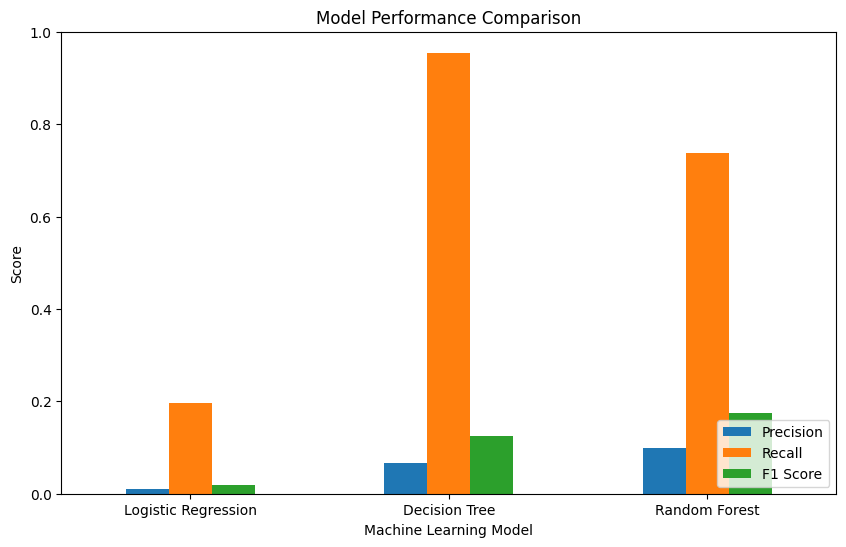

In [69]:
results_plot = results_df.set_index("Model")

results_plot[
    ["Precision", "Recall", "F1 Score"]
].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Machine Learning Model")

plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(loc="lower right")

plt.show()

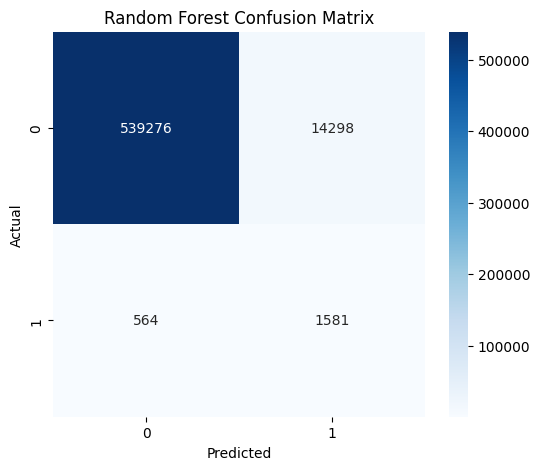

In [70]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [71]:
y_prob_rf = random_forest_model.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_prob_rf)

print("Random Forest ROC-AUC:", roc_auc)

Random Forest ROC-AUC: 0.8950137678343844


In [72]:
import joblib

joblib.dump(
    random_forest_model,
    "fraud_detection_random_forest.pkl"
)

['fraud_detection_random_forest.pkl']

In [73]:
from google.colab import files

files.download("fraud_detection_random_forest.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>